In [6]:
import pandas as pd
df=pd.read_csv(r'C:\Users\student\Desktop\iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


missng vales and data types

Matplotlib is building the font cache; this may take a moment.


<Axes: >

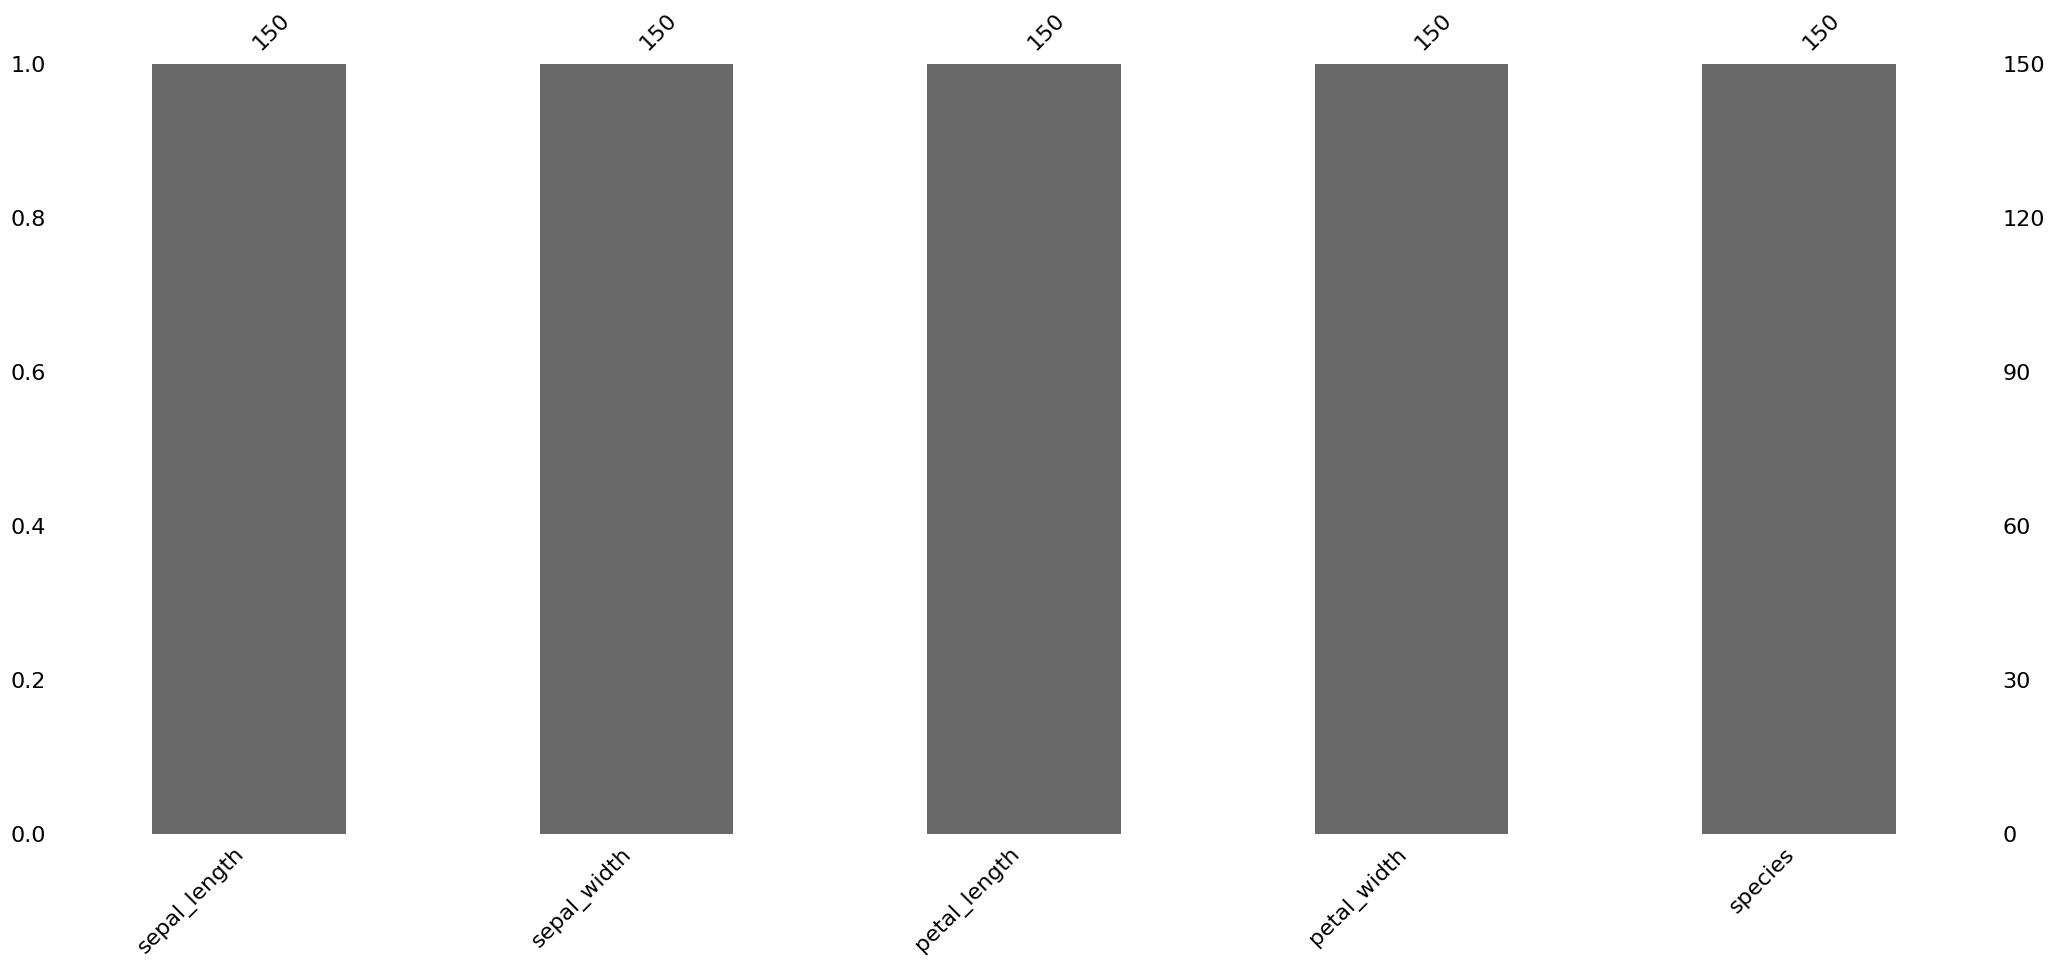

In [7]:
import missingno as mn
mn.bar(df)

there are no missing values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


NORMALIZE

In [16]:
from sklearn.preprocessing import StandardScaler as sc
s=sc()
df['sepal_length']=s.fit_transform(df[['sepal_length']])
df['petal_length']=s.fit_transform(df[['petal_length']])
df['sepal_width']=s.fit_transform(df[['sepal_width']])
df['petal_width']=s.fit_transform(df[['petal_width']])

In [17]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.900681,1.032057,-1.341272,-1.312977,setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,setosa
2,-1.385353,0.337848,-1.398138,-1.312977,setosa
3,-1.506521,0.106445,-1.284407,-1.312977,setosa
4,-1.021849,1.263460,-1.341272,-1.312977,setosa


<Axes: xlabel='sepal_width', ylabel='Count'>

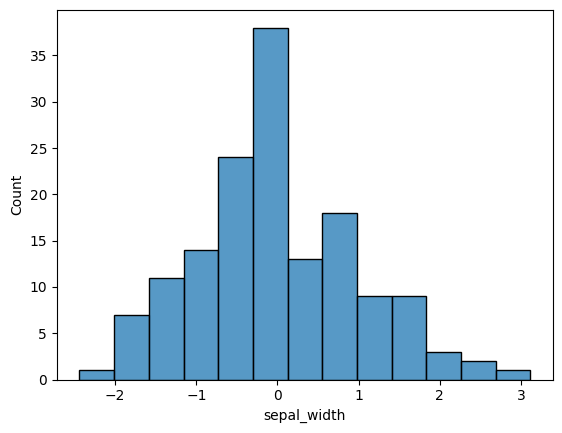

In [20]:
import seaborn as sns

sns.histplot(df['sepal_width'])

<Axes: xlabel='petal_width', ylabel='Count'>

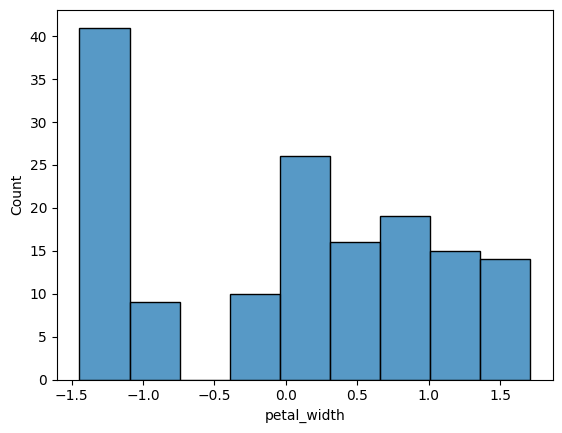

In [29]:
sns.histplot(df['petal_width'])

<Axes: xlabel='sepal_length'>

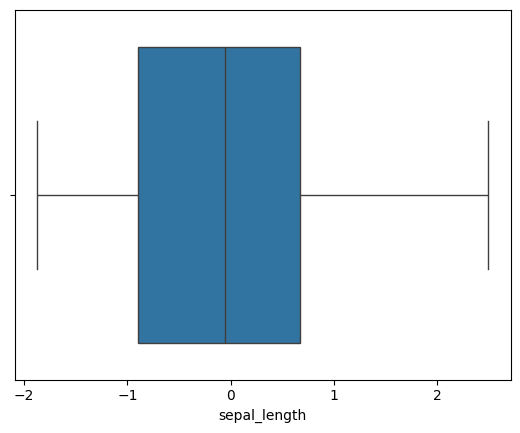

In [28]:
sns.boxplot(x=df['sepal_length'])

<Axes: xlabel='petal_length'>

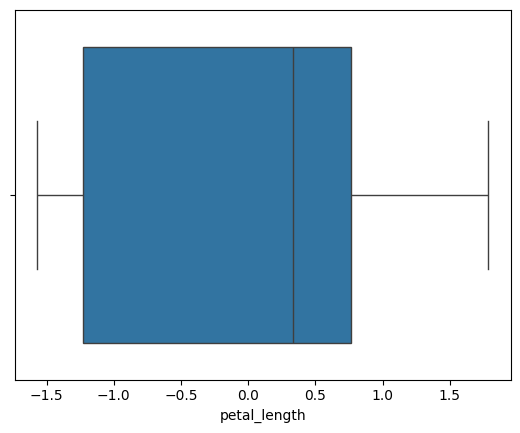

In [30]:
sns.boxplot(x=df['petal_length'])

<Axes: >

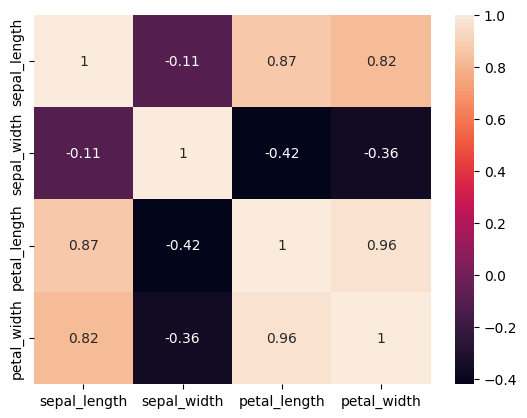

In [109]:
d=df.iloc[:,:-1]
sns.heatmap(d.corr(),annot=True)

K MEANS CLUSTERING

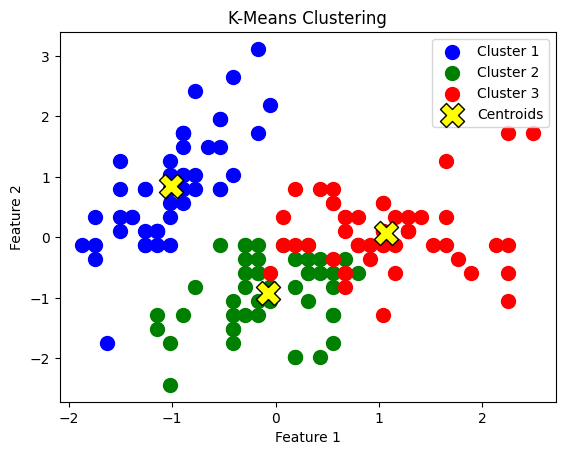

In [110]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
k=KMeans(n_clusters=3)
yp=k.fit_predict(x)


x_array = x.to_numpy()  


plt.scatter(x_array[yp == 0, 0], x_array[yp == 0, 1], s=100, c='blue', label='Cluster 1')
plt.scatter(x_array[yp == 1, 0], x_array[yp == 1, 1], s=100, c='green', label='Cluster 2')
plt.scatter(x_array[yp == 2, 0], x_array[yp == 2, 1], s=100, c='red', label='Cluster 3')

plt.scatter(k.cluster_centers_[:, 0], k.cluster_centers_[:, 1], 
            s=300, c='yellow', marker='X', edgecolors='black', label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('K-Means Clustering')
plt.show()


BUILDING MODEL
        

 RANDOM FOREST

In [69]:
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.model_selection import train_test_split as tt
from sklearn.metrics import accuracy_score as ac
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
r=rf()
xtrain,xtest,ytrain,ytest=tt(x,y,test_size=20)
r.fit(xtrain,ytrain)
p=r.predict(xtest)
a=ac(ytest,p)
print('ACCURACY SCORE: ',a)
from sklearn.metrics import precision_score as pr
ps = pr(ytest, p, average='macro')
print('PRECISION: ',ps)
from sklearn.metrics import recall_score as re
recall = re(ytest, p,average='macro')
print('RECALL : ',recall)

ACCURACY SCORE:  0.9
PRECISION:  0.9259259259259259
RECALL :  0.9047619047619048
